In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Advertising (2).csv")

In [4]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
df.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [6]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [8]:
df.isna().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [9]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

### EDA


In [10]:
df.drop('Unnamed: 0', axis=1, inplace=True)

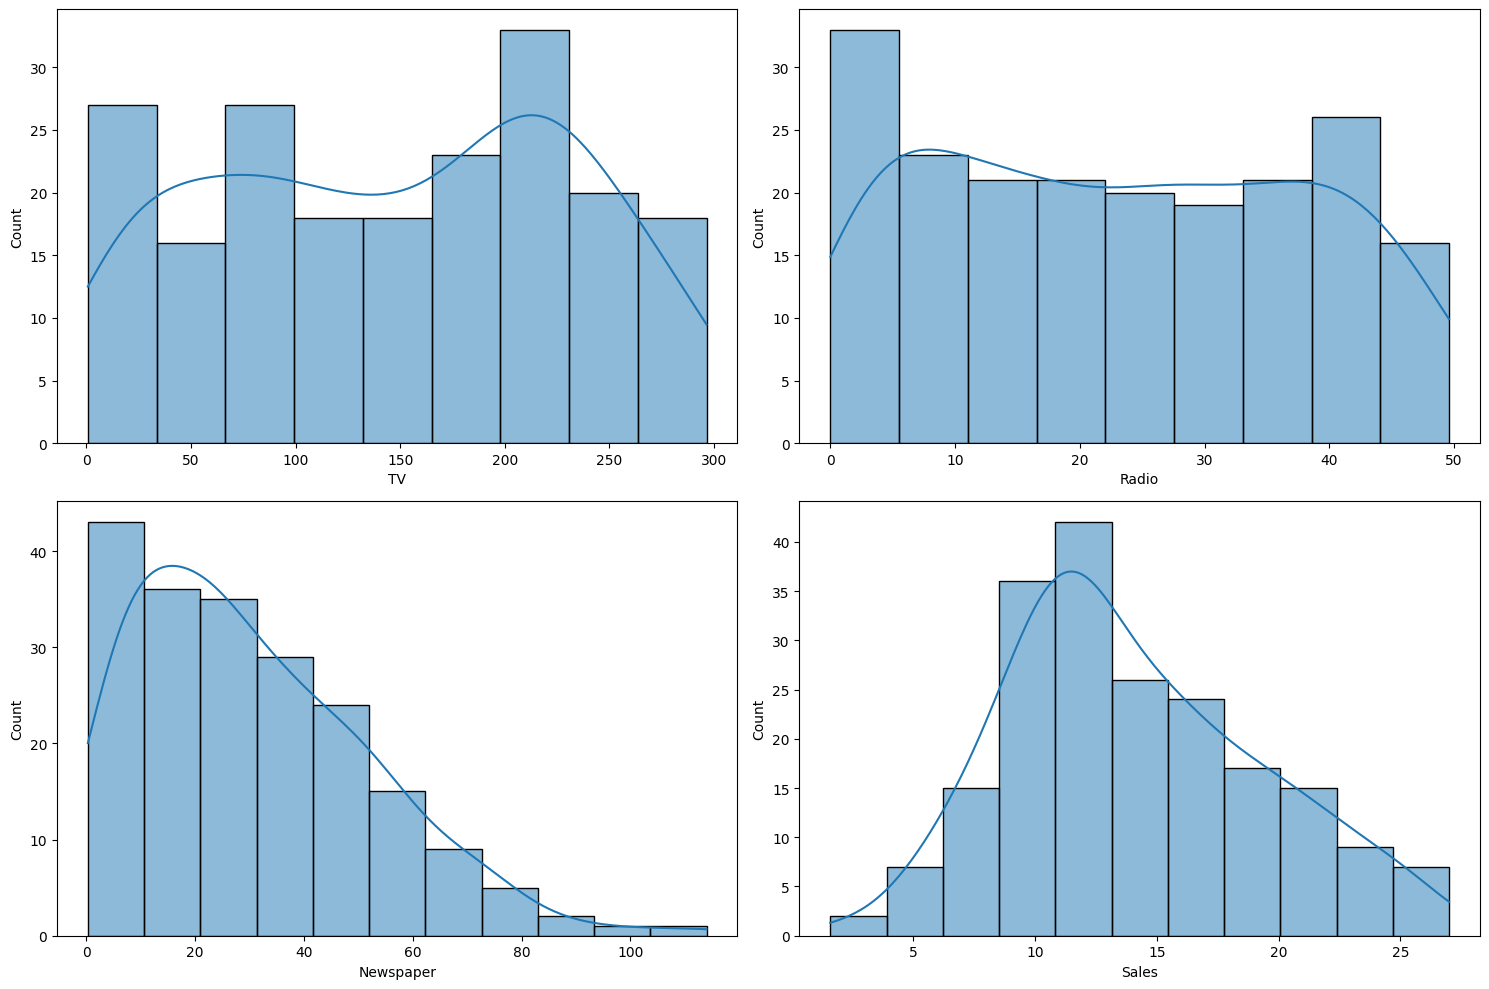

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

plotnumber = 1

for column in df.columns:
    if plotnumber <= 4:
        ax = plt.subplot(2, 2, plotnumber)
        sns.histplot(df[column], kde=True)
        plt.xlabel(column)
        plt.ylabel("Count")
    
    plotnumber += 1

plt.tight_layout()
plt.show()

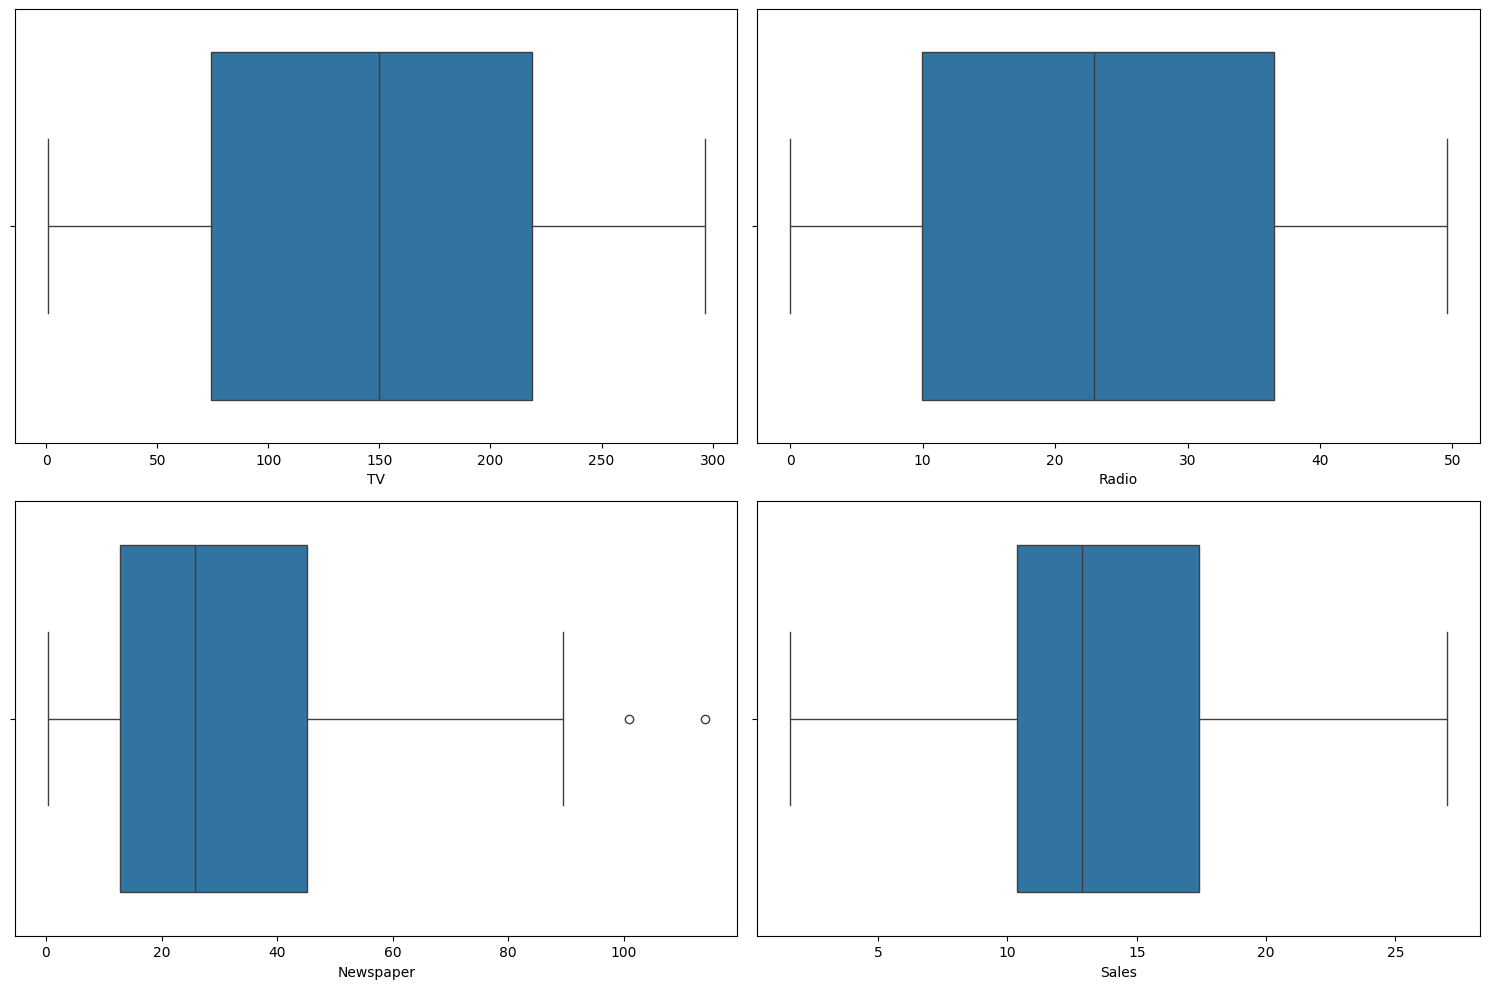

In [12]:
plt.figure(figsize=(15, 10))

plotnumber = 1

for column in df.columns:
    if plotnumber <= 4:
        ax = plt.subplot(2, 2, plotnumber)
        sns.boxplot(x=df[column])
        plt.xlabel(column)
    
    plotnumber += 1

plt.tight_layout()
plt.show()

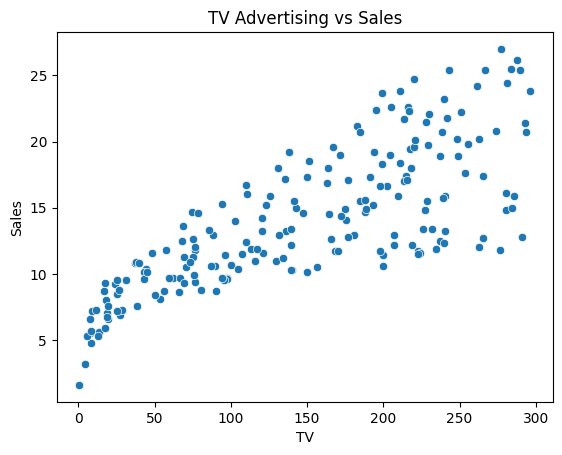

In [13]:
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title("TV Advertising vs Sales")
plt.show()

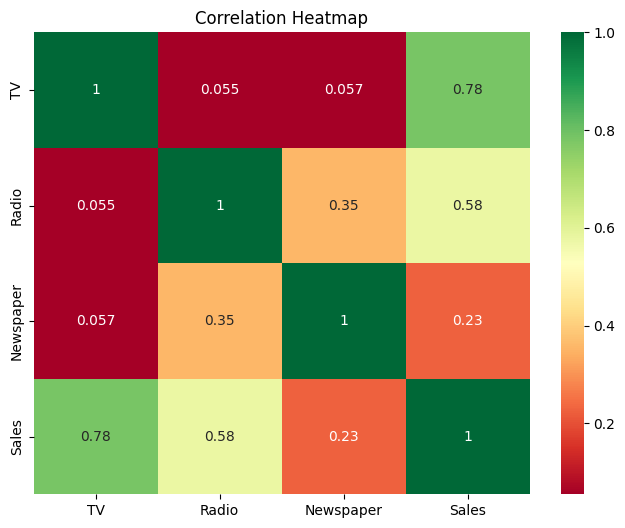

In [14]:
plt.figure(figsize=(8, 6))

sns.heatmap(df.corr(), annot=True, cmap='RdYlGn')

plt.title("Correlation Heatmap")
plt.show()

In [28]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales', 'Sales_Class'], dtype='object')

In [16]:
df['Sales_Class'] = (df['Sales'] > df['Sales'].median()).astype(int)

In [20]:
X = df.drop(['Sales', 'Sales_Class'], axis=1)
y = df['Sales_Class']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [23]:
gnb.score(X_test,y_test)

0.9

In [24]:
gnb.predict(X_test)

array([1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0])

In [25]:
y_pred = gnb.predict(X_test)

In [26]:
from sklearn.metrics import classification_report , confusion_matrix

print("Classification Report")
clf = classification_report(y_test,y_pred)
print(clf)

print("-"*40)

print("Confusion Matrix")
cm = confusion_matrix(y_test,y_pred)
print(cm)

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.88      0.91        24
           1       0.83      0.94      0.88        16

    accuracy                           0.90        40
   macro avg       0.89      0.91      0.90        40
weighted avg       0.91      0.90      0.90        40

----------------------------------------
Confusion Matrix
[[21  3]
 [ 1 15]]


<Axes: >

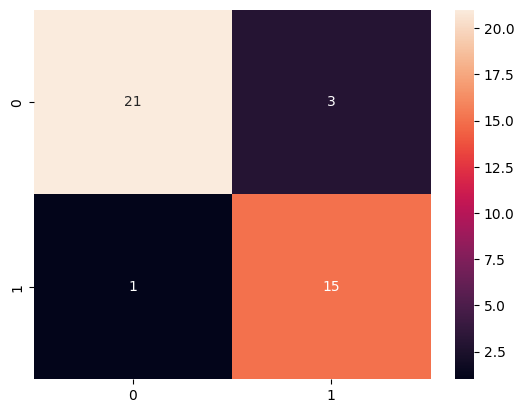

In [27]:
sns.heatmap(cm,annot=True)